# Intro to Classification

## DataCamp
- I have access to DataCamp through work. While it was helpful for initially learning ai/ml, it does not lend itself well to notetaking
- they give you a pre-prepared workspace with all of the dependencies and variables set up
- this is useful to get you into the thick of the action, but it means you have to do a lot of extra work to get the code working on your end 
- you also need to be clever and do manual work to extract datasets from the site
- on top of all of that, you need to click through each step of the lesson to get to the code snippets, so if you don't spend the extra time to extract the notes as you go, it takes even longer to go back and extract them later

### Extracting DataFrames from DataCamp
1. Run `pd.to_csv` on the DataFrame in the interactive window
2. Use `Shift` + `Down` to select the text
3. Copy and Paste into a `.csv` file
4. Find and Replace `\n` with `/`
5. Activate Regex mode (`.*`)
6. Find and Replace `/` with `\n`
7. remove the extra apostrophes (`'`) from the start and end of the text

### About this Course
- [Intro to Classification](https://campus.datacamp.com/courses/supervised-learning-with-scikit-learn/classification-1?ex=1) is the first part of the course [Supervised Learning with scikit-learn](https://app.datacamp.com/learn/courses/supervised-learning-with-scikit-learn) which is the first course on the track [Machine Learning Scientist in Python](https://app.datacamp.com/learn/career-tracks/machine-learning-scientist-with-python).
- [Intro to Regression](https://campus.datacamp.com/courses/supervised-learning-with-scikit-learn/regression-7f892f18-f9c3-4c6f-9570-f19ed117c967?ex=1) is the second part of this course, but it I don't appear to have extracted those notes, and it would be time consuming to do so now

## Intro to Classification
- Basic Terminology
    - **Supervised Learning** - the values to be predicted are already known, goal is to predict values of previously unseen data
    - **Classification** - predict the label or category of an observations (like "is a transaction fraudulent or not?")

### k-Nearest Neighbors
- **Binary Classification** - classification where there are only two outcomes to choose between
- **k-Nearest Neighbors** - predict the label of a data point by looking at the `k` closest labeled data points
- so for `k=5`, you find the `5` closest points to your target point and give it the same label as the majority of those 
- you'd think you'd need an odd number, but they use even numbers in examples too

In [1]:
# import everything
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

### The Churn Dataset
- contains data on customer accounts such as account age
- we will try to predict whether a customer will leave (the "churn") based on this data

In [ ]:
# Read in the churn dataset
churn_df = pd.read_csv(Path().cwd() / "churn.csv", index_col=0)
churn_df

,account_length,total_day_charge,total_eve_charge,total_night_charge,total_intl_charge,customer_service_calls,churn
0,101,45.85,17.65,9.64,1.22,3,1
1,73,22.30,9.05,9.98,2.75,2,0
2,86,24.62,17.53,11.49,3.13,4,0
3,59,34.73,21.02,9.66,3.24,1,0
4,129,27.42,18.75,10.11,2.59,1,0
...,...,...,...,...,...,...,...
3328,89,51.66,22.18,14.04,1.43,1,1
3329,141,43.96,18.87,14.69,3.02,0,0
3330,111,42.47,20.60,10.43,3.13,0,1
3331,135,46.48,13.09,11.06,3.32,1,0


### Choose Data
- features
    - choose `account_length` as it might indicate loyalty
    - choose `customer_service_calls` as it might indicate dissatisfaction
- target
    - choose `churn` since that's what we're trying to predict

In [3]:
# pull the features and target out of the larger DataFrame
y = churn_df["churn"].values
X = churn_df[["account_length", "customer_service_calls"]].values
# create the unseen data to predict on later (each point has contains an account length and customer service calls)
X_new = np.array([[30.0, 17.5], [107.0, 24.1], [213.0, 10.9]])
print(f"feature shape: {X.shape}, target shape: {y.shape}")

feature shape: (3333, 2), target shape: (3333,)


### Fit
fit the classifier to the data

In [4]:
# Create a KNN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)
# Fit the classifier to the data
knn.fit(X, y)

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Predict
use the classifier to predict the churn for unseen data

In [5]:
predictions = knn.predict(X_new)
predictions  # churn predictions for the 3 X_new data points: [0, 1, 0]

array([0, 1, 0])

### Measuring Model Performance (train-test-split)
- accuracy is one performance metric
- $\text{accuracy} = \frac{\text{correct predictions}}{\text{number of observations}}$
- need to measure how well it predicts unseen data - split into `training` and `test` sets
- train it on the `training` set (typically use `70%` for `training`)
- test its accuracy on the (unseen) `test` set (typically reserve `30%` for `testing`)

In [6]:
# split the data up into training and test sets, use 70% for training and 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,  # reserve 30% of the dataset for testing
    random_state=21,  # set the random seed or it will reserve different data each time
    stratify=y, # ensure that the test data has the same proportion of churn vs non-churn as the overall population
)
# fit the classifier and score how well it predicts the test data
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)
knn.score(X_test, y_test) # 0.869 - not amazing

0.858

### Model Complexity (Overfitting/Underfitting)
- as you increase the `k` (number of neighbors), the model gets **less complex** (that seems backwards)
- **more neighbors** → **less complex model** → **underfitting**
    - less capable of detecting relationships in the dataset
- **fewer neighbors** → **more complex model** → **overfitting**
    - too well fit to the **training data** to generalize well to **test data**
    - vulnerable to fitting to **noise**
- here is the **decision boundary** predicting **target** `churn` based on  **features** `total_eve_charge` and `total_day_charge` for a variety of `k` (**number of neighbors**) 
    - as `k` increases, the boundary is less affected by individual points (once `k = sample size`, every point is just the average of all the other points)
    - starts out too **complex/overfitting**, eventually plateaus as it becomes too **simple/underfitting**
- <img src="../../../images/knn_churn.png" width="650">

best accuracy '0.8770614692653673' occurs at '7' neighbors


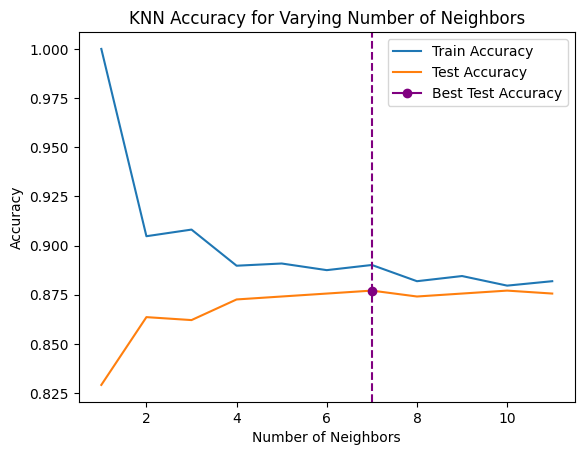

In [7]:
# this time use all of the features to predict the target
X = churn_df.drop("churn", axis=1).values
y = churn_df["churn"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# fit and calculate and accuracy for various numbers of neighbors
train_accuracies = {}
test_accuracies = {}
neighbors = np.arange(1, 12)
for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train, y_train)
    train_accuracies[neighbor] = knn.score(X_train, y_train)
    test_accuracies[neighbor] = knn.score(X_test, y_test)

# figure out the number of neighbors giving the highest test accuracy
best_neighbor = max(test_accuracies, key=test_accuracies.get)
max_test_accuracy = test_accuracies[best_neighbor]
print(f"best accuracy '{max_test_accuracy}' occurs at '{best_neighbor}' neighbors")

# create a plot with the accuracy for each number of neighbors
plt.plot(neighbors, train_accuracies.values(), label="Train Accuracy")
plt.plot(neighbors, test_accuracies.values(), label="Test Accuracy")
plt.plot(best_neighbor, max_test_accuracy, color='purple', marker='o', label="Best Test Accuracy")
plt.axvline(best_neighbor, color='purple', linestyle='--')
plt.title("KNN Accuracy for Varying Number of Neighbors")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.show()